In [1]:
from __future__ import annotations
from helpers.env import ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt
from ModifiedSlipperyGridWorld import ModifiedSlipperyGridWorld
from algorithms import ValueIteration, QLearning, SARSA, DynaQ

In [2]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


# BIG ENVIRONMENT

In [3]:
# Grid parameters
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10
walls = [(0, 2), (2, 0)]
traps = [(3, 3)]
trap_rewards=[-40]
add_goals = [(0, 6), (4, 0)]
add_goals_rewards = [10, 10]

# Evaluation parameters
max_steps_in_env = 200 # used for episodic evaluation
plot_vmin = np.min(trap_rewards)
plot_vmax = np.max(add_goals_rewards+[goal_reward])

env = ModifiedSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed,
                                walls=walls,  terminal_traps=traps, trap_rewards=trap_rewards, additional_goals=add_goals, additional_goal_rewards=add_goals_rewards)

## Value Iteration

In [4]:
# Value iteration parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

V, pi = ValueIteration(env, max_number_iterations=max_number_iterations, gamma=gamma, threshold=threshold)

Iterations count: 52


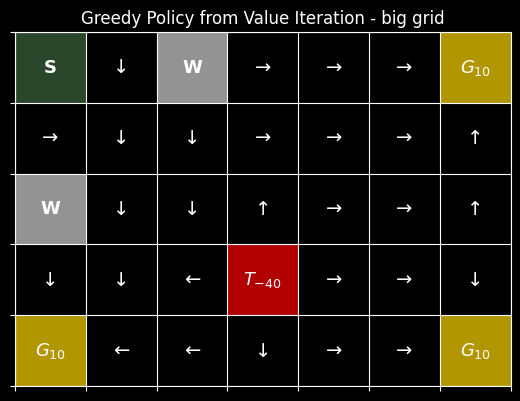

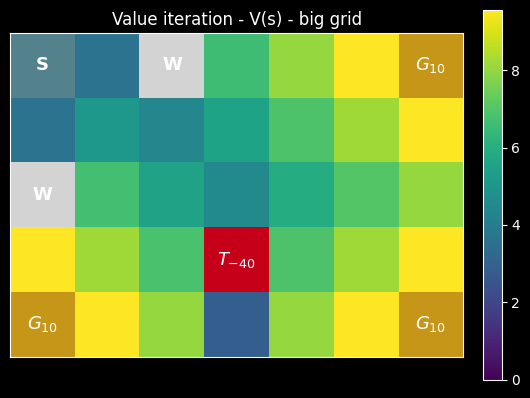

Value iteration - big grid:  {'avg_return': 0.52, 'std_return': 11.6314, 'success_rate': 0.94, 'trap_rate': 0.06, 'avg_steps': 7.48}


In [5]:
policy_plot_name = "policy_VI_big.png"
value_plot_name = "value_VI_big.png"
gif_name = "episode_VI_big.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Value Iteration - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Value iteration - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Value iteration - big grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## QLearning

In [6]:
alpha = 0.15
epsilon = 0.1
gamma = 0.99
max_iterations = 5000

V, pi = QLearning(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

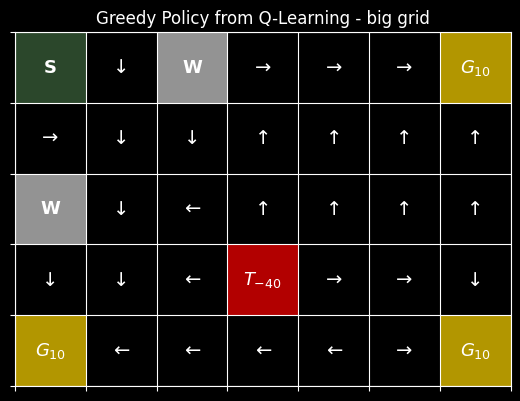

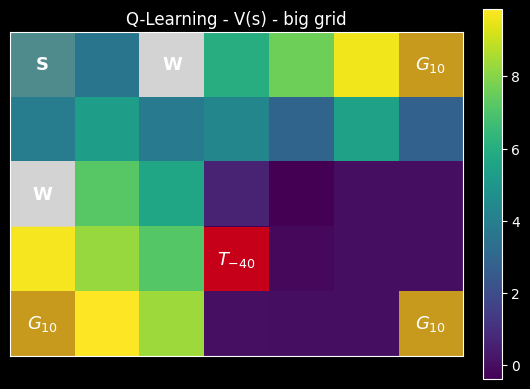

Q-Learning - big grid:  {'avg_return': 1.52, 'std_return': 9.6358, 'success_rate': 0.96, 'trap_rate': 0.04, 'avg_steps': 7.48}


In [7]:
policy_plot_name = "policy_QL_big.png"
value_plot_name = "value_QL_big.png"
gif_name = "episode_QL_big.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Q-Learning - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Q-Learning - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Q-Learning - big grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## SARSA

In [8]:
alpha = 0.15
epsilon = 0.1
gamma = 0.99
max_iterations = 5000

V, pi = SARSA(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

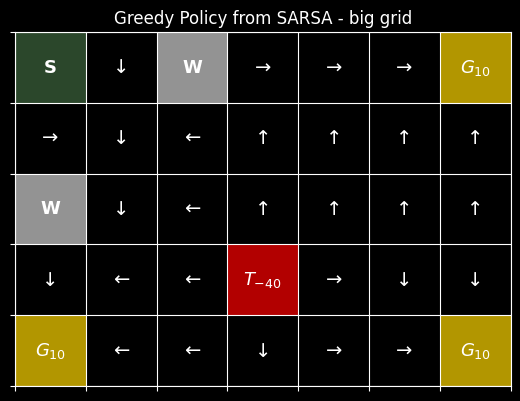

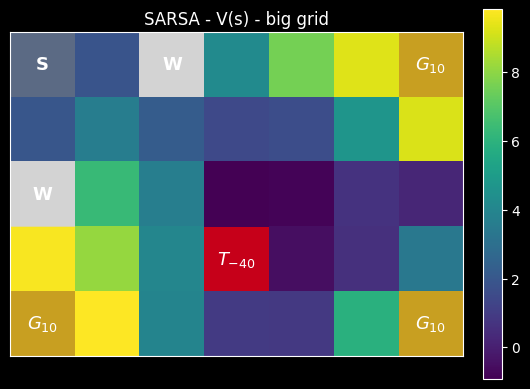

SARSA - big grid:  {'avg_return': 1.9, 'std_return': 7.0036, 'success_rate': 0.98, 'trap_rate': 0.02, 'avg_steps': 8.1}


In [9]:
policy_plot_name = "policy_SARSA_big.png"
value_plot_name = "value_SARSA_big.png"
gif_name = "episode_SARSA_big.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from SARSA - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="SARSA - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("SARSA - big grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## DynaQ


In [10]:
alpha = 0.15
epsilon = 0.1
gamma = 0.99
max_iterations = 5000
n=5

V, pi = DynaQ(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations, n=n)

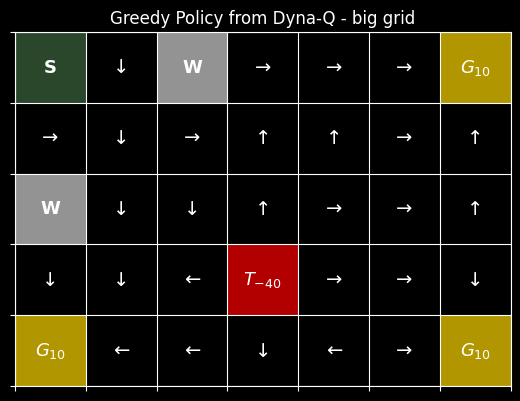

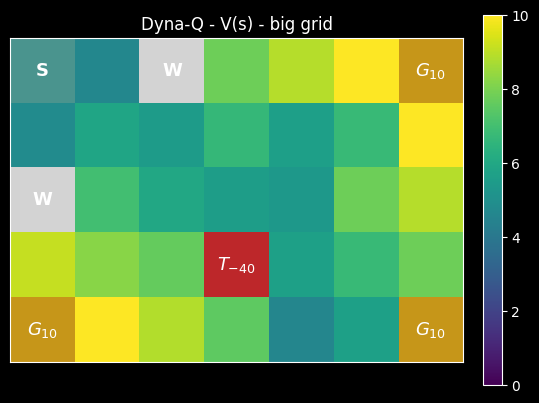

Dyna-Q - big grid:  {'avg_return': 1.42, 'std_return': 9.4511, 'success_rate': 0.96, 'trap_rate': 0.04, 'avg_steps': 7.58}


In [11]:
policy_plot_name = "policy_DynaQ_big.png"
value_plot_name = "value_DynaQ_big.png"
gif_name = "episode_DynaQ_big.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Dyna-Q - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Dyna-Q - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Dyna-Q - big grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# SMALL ENVIRONMENT

In [12]:
# Grid parameters
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10
walls = [(0, 2), (2, 0)]
traps = [(3, 3)]
trap_rewards=[-40]
add_goals = [(0, 6), (4, 0)]
add_goals_rewards = [10, 10]

# Evaluation parameters
max_steps_in_env = 200 # used for episodic evaluation
plot_vmin = np.min(trap_rewards)
plot_vmax = np.max(add_goals_rewards+[goal_reward])

env = ModifiedSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed,
                                walls=walls,  terminal_traps=traps, trap_rewards=trap_rewards, additional_goals=add_goals, additional_goal_rewards=add_goals_rewards)

## Value Iteration

In [13]:
# Value iteration parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor
alpha = 0.15

V, pi = ValueIteration(env, max_number_iterations=max_number_iterations, gamma=gamma, threshold=threshold)

Iterations count: 52


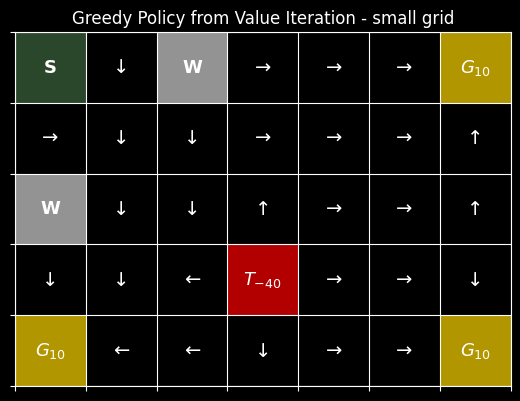

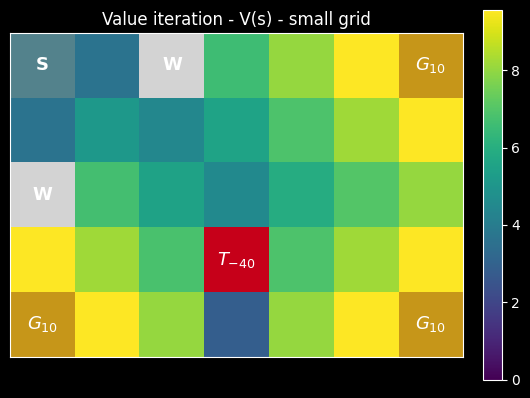

Value iteration - small grid:  {'avg_return': 0.6, 'std_return': 11.3877, 'success_rate': 0.94, 'trap_rate': 0.06, 'avg_steps': 7.4}


In [14]:
policy_plot_name = "policy_VI_small.png"
value_plot_name = "value_VI_small.png"
gif_name = "episode_VI_small.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Value Iteration - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Value iteration - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Value iteration - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## QLearning

In [15]:
alpha = 0.15
epsilon = 0.1
gamma = 0.99
max_iterations = 5000

V, pi = QLearning(env=env, epsilon=0.1, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

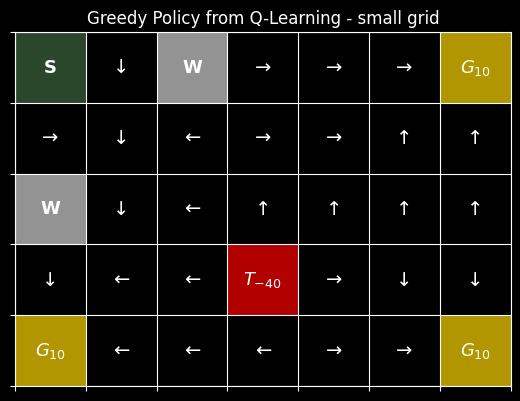

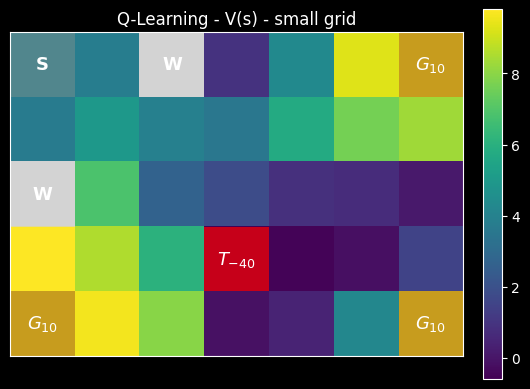

Q-Learning - small grid:  {'avg_return': 2.84, 'std_return': 2.4606, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 8.16}


In [16]:
policy_plot_name = "policy_QL_small.png"
value_plot_name = "value_QL_small.png"
gif_name = "episode_QL_small.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Q-Learning - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Q-Learning - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Q-Learning - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## SARSA


In [17]:
alpha = 0.15
epsilon = 0.1
gamma = 0.99
max_iterations = 5000

V, pi = SARSA(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

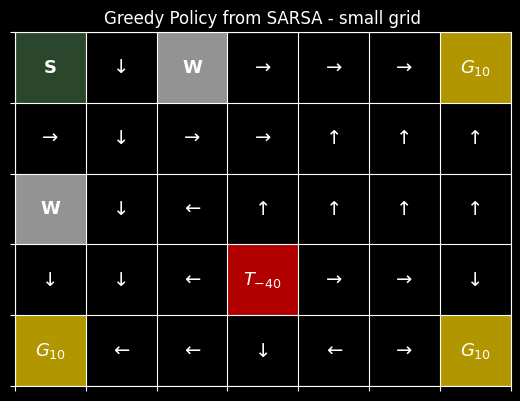

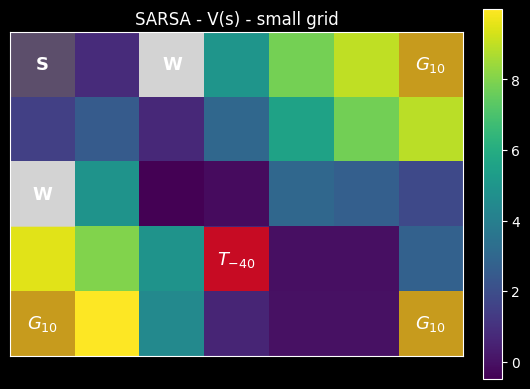

SARSA - small grid:  {'avg_return': 2.34, 'std_return': 6.9242, 'success_rate': 0.98, 'trap_rate': 0.02, 'avg_steps': 7.66}


In [18]:
policy_plot_name = "policy_SARSA_small.png"
value_plot_name = "value_SARSA_small.png"
gif_name = "episode_SARSA_small.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from SARSA - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="SARSA - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("SARSA - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## Dyna-Q

In [19]:
alpha = 0.15
epsilon = 0.1
gamma = 0.99
max_iterations = 5000
n=5

V, pi = DynaQ(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations, n=n)

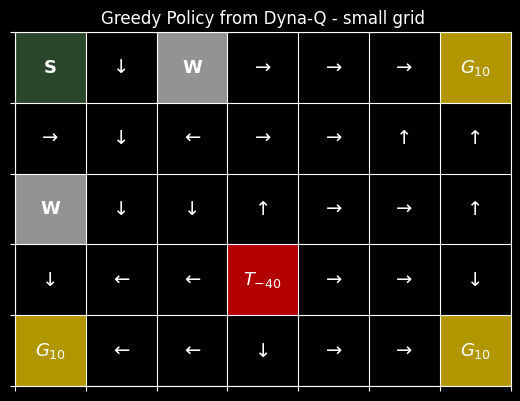

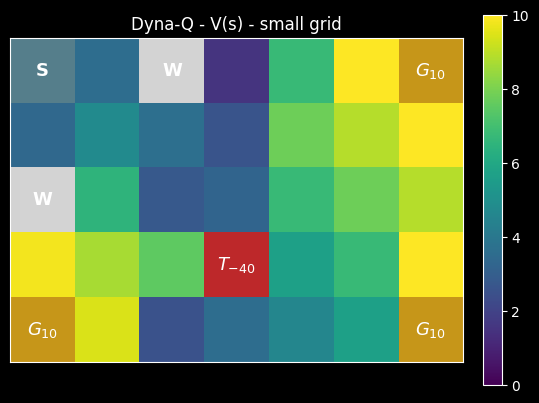

Dyna-Q - small grid:  {'avg_return': 2.84, 'std_return': 2.361, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 8.16}


In [20]:
policy_plot_name = "policy_DynaQ_small.png"
value_plot_name = "value_DynaQ_small.png"
gif_name = "episode_DynaQ_small.gif"
n_val_episodes = 50

env.reset()

pi = greedy_policy_from_V(V, env, gamma)

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Dyna-Q - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Dyna-Q - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Dyna-Q - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# COMPARISON and PARAMETERS EXPERIMENTS